# Projet 12 - ZenAssist : Étape 1 - Analyse Exploratoire des Données (EDA)

Ce notebook présente l'analyse exploratoire complète du dataset de réclamations clients de ZenAssist (`dataset.csv`).

### Objectifs :
1. **Charger et explorer la structure des données**.
2. **Filtrer et nettoyer les données** (gestion des valeurs nulles, doublons et masques CFPB).
3. **Harmoniser la taxonomie des catégories (`Tag`)**.
4. **Visualiser la distribution des catégories et la longueur des réclamations**.
5. **Créer les jeux d'entraînement, de test et le sous-échantillon pour LLM (~1 000 exemples)**.
6. **Formaliser la métrique de latence (temps de réponse)**.

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Configuration style graphique
plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

## 1. Chargement et inspection initiale

In [11]:
# chargement du dataset
csv_path = 'dataset/dataset.csv'
df = pd.read_csv(csv_path, low_memory=False)

In [12]:
# nombre de lignes
print(f'Nombre total de lignes : {len(df):,}')

Nombre total de lignes : 1,282,355


In [13]:
# colonnes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 15 columns):
 #   Column                        Non-Null Count    Dtype
---  ------                        --------------    -----
 0   Date received                 1282355 non-null  str  
 1   Tag                           1282355 non-null  str  
 2   Consumer Claim                383564 non-null   str  
 3   Company public response       449082 non-null   str  
 4   Company                       1282355 non-null  str  
 5   State                         1262955 non-null  str  
 6   ZIP code                      1167057 non-null  str  
 7   Tags                          175643 non-null   str  
 8   Consumer consent provided?    690654 non-null   str  
 9   Submitted via                 1282355 non-null  str  
 10  Date sent to company          1282355 non-null  str  
 11  Company response to consumer  1282348 non-null  str  
 12  Timely response?              1282355 non-null  str  
 13  Consumer

In [ ]:
#aperçu
df.head()

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [ ]:
# on restreint aux colonnes utiles
usecols = ['Date received', 'Tag', 'Consumer Claim',   'Company']
df = df[usecols].copy()
df.head()

,Date received,Tag,Consumer Claim,Company
0,05/10/2019,Checking or savings account,NaN,NAVY FEDERAL CREDIT UNION
1,05/10/2019,Checking or savings account,NaN,BOEING EMPLOYEES CREDIT UNION
2,05/10/2019,Debt collection,NaN,CURO Intermediate Holdings
3,05/10/2019,"Credit reporting, credit repair services, or o...",NaN,Ad Astra Recovery Services Inc
4,05/10/2019,Checking or savings account,NaN,ALLY FINANCIAL INC.


## 2. Nettoyage et Filtrage des Réclamations

In [16]:
# Filtrer les lignes sans texte de réclamation
df_clean = df.dropna(subset=['Consumer Claim']).copy()
df_clean['Consumer Claim'] = df_clean['Consumer Claim'].astype(str).str.strip()
df_clean = df_clean[df_clean['Consumer Claim'] != '']
print(f'Lignes avec texte réclamations : {len(df_clean):,} ({len(df_clean)/len(df)*100:.2f}%)')

Lignes avec texte réclamations : 383,564 (29.91%)


In [17]:
# Suppression des doublons exacts
df_clean = df_clean.drop_duplicates(subset=['Consumer Claim', 'Tag'])
print(f'Nombre de réclamations uniques : {len(df_clean):,}')

Nombre de réclamations uniques : 367,123


## 3. Harmonisation de la taxonomie des catégories (`Tag`)

In [19]:
# 1. Inspection préalable des Tags bruts existants
print("--- 1. Liste et comptage des Tags bruts ---")
raw_tags_distribution = df_clean['Tag'].value_counts(dropna=False)
print(f"Nombre de catégories uniques brutes : {df_clean['Tag'].nunique()}")
print(raw_tags_distribution)

--- 1. Liste et comptage des Tags bruts ---
Nombre de catégories uniques brutes : 18
Tag
Debt collection                                                                 84317
Credit reporting, credit repair services, or other personal consumer reports    80466
Mortgage                                                                        52945
Credit reporting                                                                29827
Student loan                                                                    21781
Credit card or prepaid card                                                     21292
Credit card                                                                     18757
Bank account or service                                                         14856
Checking or savings account                                                     12858
Consumer Loan                                                                    9443
Vehicle loan or lease                              

In [20]:

# 2. Dictionnaire d'harmonisation de la taxonomie
tag_mapping = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit reporting',
    'Credit reporting': 'Credit reporting',
    'Credit card or prepaid card': 'Credit card / Prepaid card',
    'Credit card': 'Credit card / Prepaid card',
    'Prepaid card': 'Credit card / Prepaid card',
    'Bank account or service': 'Bank account / Savings',
    'Checking or savings account': 'Bank account / Savings',
    'Payday loan, title loan, or personal loan': 'Payday & Personal loan',
    'Payday loan': 'Payday & Personal loan',
    'Consumer Loan': 'Payday & Personal loan',
    'Money transfer, virtual currency, or money service': 'Money transfer / Crypto',
    'Money transfers': 'Money transfer / Crypto',
    'Virtual currency': 'Money transfer / Crypto',
    'Mortgage': 'Mortgage',
    'Student loan': 'Student loan',
    'Vehicle loan or lease': 'Vehicle loan / Lease',
    'Debt collection': 'Debt collection',
    'Other financial service': 'Other financial service'
}

# 3. Application du mapping et affichage des catégories nettoyées
df_clean['Tag_Clean'] = df_clean['Tag'].map(tag_mapping).fillna(df_clean['Tag'])

print("\n--- 2. Liste et comptage des Tags harmonisés ---")
clean_tag_counts = df_clean['Tag_Clean'].value_counts()
print(f"Nombre de catégories uniques nettoyées : {df_clean['Tag_Clean'].nunique()}")
print(clean_tag_counts)


--- 2. Liste et comptage des Tags harmonisés ---
Nombre de catégories uniques nettoyées : 10
Tag_Clean
Credit reporting              110293
Debt collection                84317
Mortgage                       52945
Credit card / Prepaid card     41497
Bank account / Savings         27714
Student loan                   21781
Payday & Personal loan         15598
Money transfer / Crypto         6967
Vehicle loan / Lease            5720
Other financial service          291
Name: count, dtype: int64


## 4. Visualisations de l'Analyse Exploratoire

/tmp/ipykernel_7480/1204978342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clean_tag_counts.values, y=clean_tag_counts.index, ax=axes[0], palette='viridis')


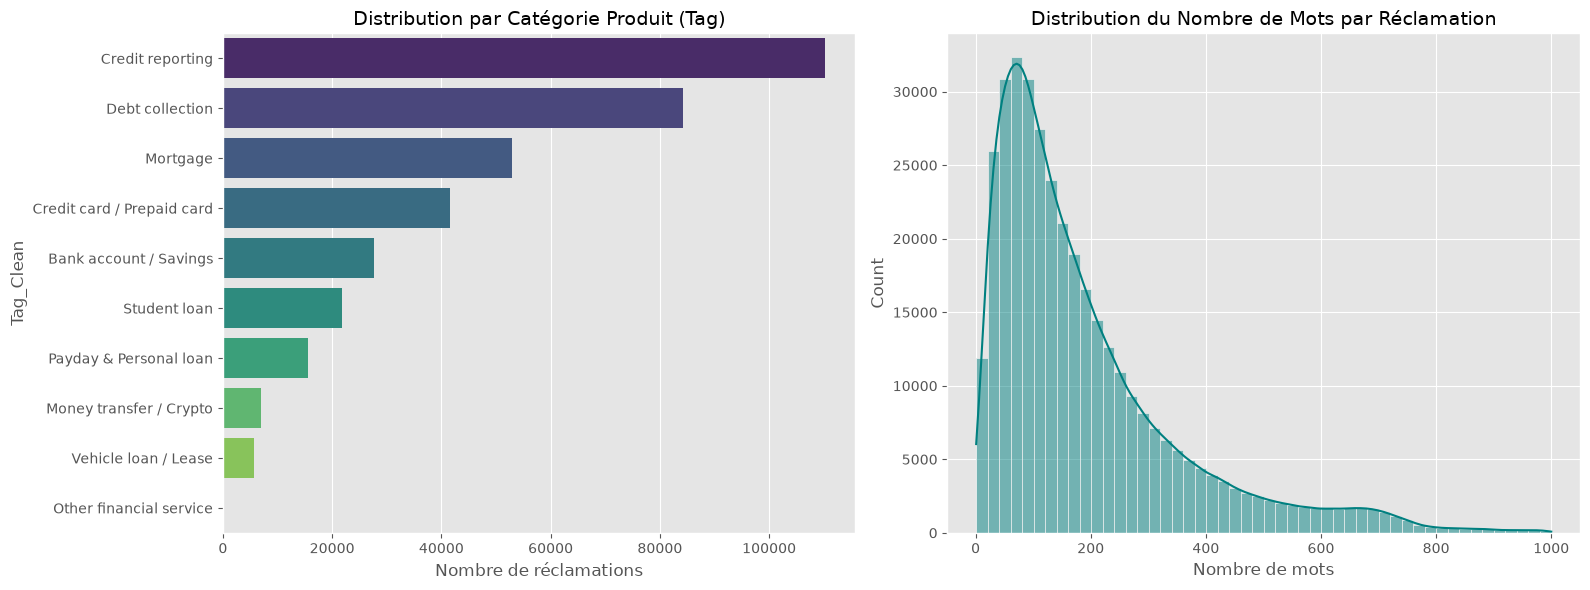

In [21]:
df_clean['word_count'] = df_clean['Consumer Claim'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=clean_tag_counts.values, y=clean_tag_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution par Catégorie Produit (Tag)', fontsize=14)
axes[0].set_xlabel('Nombre de réclamations')

sns.histplot(df_clean[df_clean['word_count'] <= 1000]['word_count'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution du Nombre de Mots par Réclamation', fontsize=14)
axes[1].set_xlabel('Nombre de mots')

plt.tight_layout()
plt.show()

/tmp/ipykernel_7480/3923209809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['word_count'] <= 1000], x='word_count', y='Tag_Clean', palette='viridis')


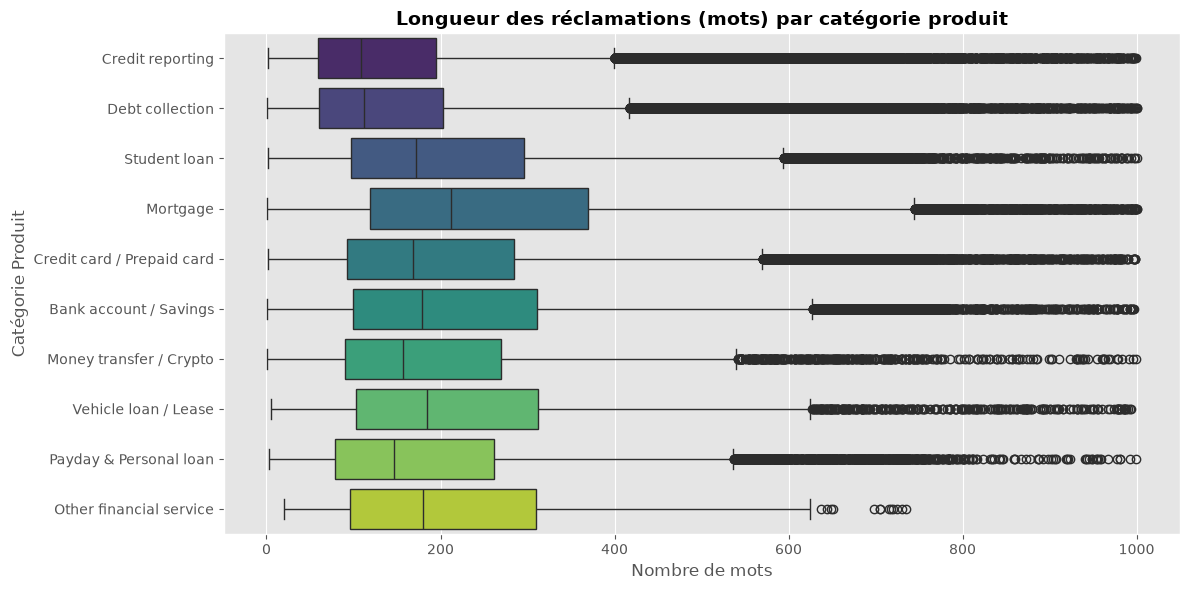

In [22]:
plt.figure(figsize=(12, 6))
# On limite aux réclamations de <= 1000 mots pour la lisibilité
sns.boxplot(data=df_clean[df_clean['word_count'] <= 1000], x='word_count', y='Tag_Clean', palette='viridis')
plt.title('Longueur des réclamations (mots) par catégorie produit', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de mots')
plt.ylabel('Catégorie Produit')
plt.tight_layout()
plt.show()

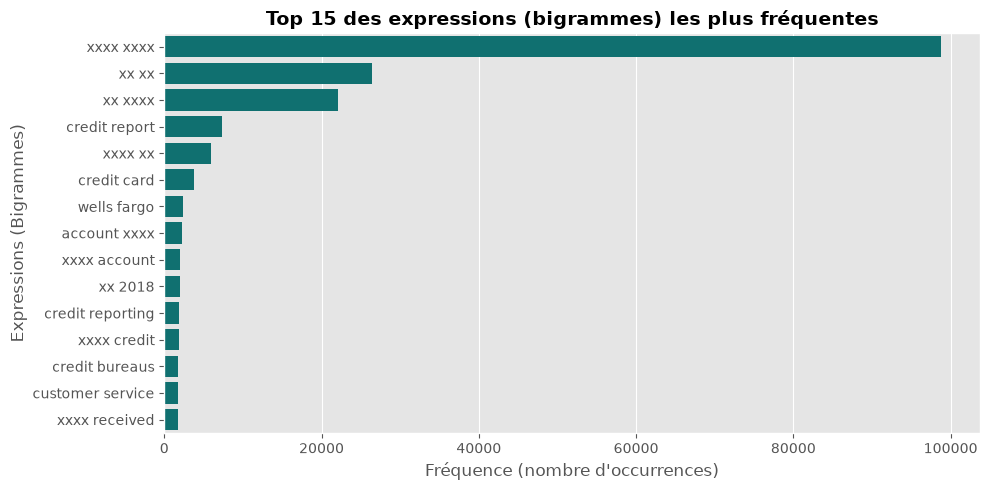

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# Extrait les 15 bigrammes (mots de 2 termes) les plus fréquents
vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=15)
bag_of_words = vec.fit_transform(df_clean['Consumer Claim'].dropna().sample(20000, random_state=42))
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

df_words = pd.DataFrame(words_freq, columns=['Bigramme', 'Fréquence'])

plt.figure(figsize=(10, 5))
# Utilisation de color='teal' ou palette='viridis' avec hue
sns.barplot(x='Fréquence', y='Bigramme', data=df_words, color='teal')
plt.title('Top 15 des expressions (bigrammes) les plus fréquentes', fontsize=14, fontweight='bold')
plt.xlabel('Fréquence (nombre d\'occurrences)')
plt.ylabel('Expressions (Bigrammes)')
plt.tight_layout()
plt.show()

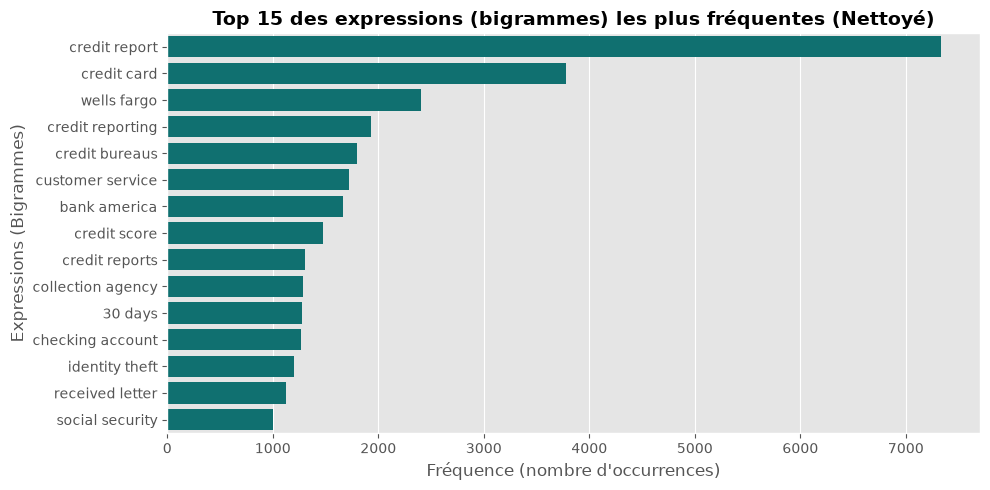

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# 1. Ajout des masques d'anonymisation (xxxx, xx, etc.) aux stop words
custom_stop_words = list(ENGLISH_STOP_WORDS) + ['xxxx', 'xx', 'xxxxxx', 'x', '00']

# 2. Vectorisation nettoyée
vec = CountVectorizer(ngram_range=(2, 2), stop_words=custom_stop_words, max_features=15)
bag_of_words = vec.fit_transform(df_clean['Consumer Claim'].dropna().sample(20000, random_state=42))
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

df_words = pd.DataFrame(words_freq, columns=['Bigramme', 'Fréquence'])

# 3. Affichage du graphique propre
plt.figure(figsize=(10, 5))
sns.barplot(x='Fréquence', y='Bigramme', data=df_words, color='teal')
plt.title('Top 15 des expressions (bigrammes) les plus fréquentes (Nettoyé)', fontsize=14, fontweight='bold')
plt.xlabel('Fréquence (nombre d\'occurrences)')
plt.ylabel('Expressions (Bigrammes)')
plt.tight_layout()
plt.show()

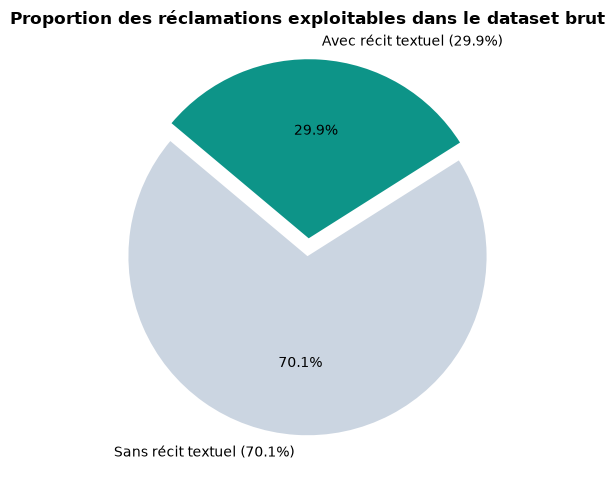

In [27]:
has_text_counts = df['Consumer Claim'].notnull().value_counts()

plt.figure(figsize=(6, 5))
plt.pie(has_text_counts, labels=['Sans récit textuel (70.1%)', 'Avec récit textuel (29.9%)'], 
        colors=['#CBD5E1', '#0D9488'], autopct='%1.1f%%', startangle=140, explode=(0, 0.1))
plt.title('Proportion des réclamations exploitables dans le dataset brut', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Découpage des jeux de données (Train, Test & LLM Sample)

In [26]:
valid_tags = clean_tag_counts[clean_tag_counts >= 50].index
df_filtered = df_clean[df_clean['Tag_Clean'].isin(valid_tags)].copy()

train_df, test_df = train_test_split(df_filtered, test_size=0.20, random_state=42, stratify=df_filtered['Tag_Clean'])
llm_sample_df, _ = train_test_split(test_df, train_size=1000, random_state=42, stratify=test_df['Tag_Clean'])

print(f'Train set : {len(train_df):,} exemples')
print(f'Test set complet : {len(test_df):,} exemples')
print(f'LLM Test Sample : {len(llm_sample_df):,} exemples')

train_df[['Consumer Claim', 'Tag_Clean']].to_csv('dataset/processed_train.csv', index=False)
test_df[['Consumer Claim', 'Tag_Clean']].to_csv('dataset/processed_test.csv', index=False)
llm_sample_df[['Consumer Claim', 'Tag_Clean']].to_csv('dataset/llm_test_sample.csv', index=False)
print('Fichiers CSV sauvegardés avec succès !')

Train set : 293,698 exemples
Test set complet : 73,425 exemples
LLM Test Sample : 1,000 exemples
Fichiers CSV sauvegardés avec succès !
